In [9]:
from utilities import utils_tomo
import numpy as np
import astra
import matplotlib.pyplot as plt

In [70]:
folder = '/mnt/share/ALC_ptychography_alignment/Experimental/connor_wright'
filename = folder + '/scan_275019_275199_tomo_complex.nxs'
data_key = '/entry1/data'
angle_key = '/entry1/rotation_angle'

stack_object, theta, _ = utils_tomo.load_data(filename, data_key= data_key, angle_key = angle_key)
print(stack_object.shape)
# stack_object = stack_object.transpose((1,2,0))
stack_object = stack_object.transpose((1,0,2)) # for astra
print(stack_object.shape)
[Ny, Nangles, Nx] = stack_object.shape

raw data shape: (181, 582, 740)
projections shape: (181, 582, 740)
angles shape: (181,)
(181, 582, 740)
(582, 181, 740)


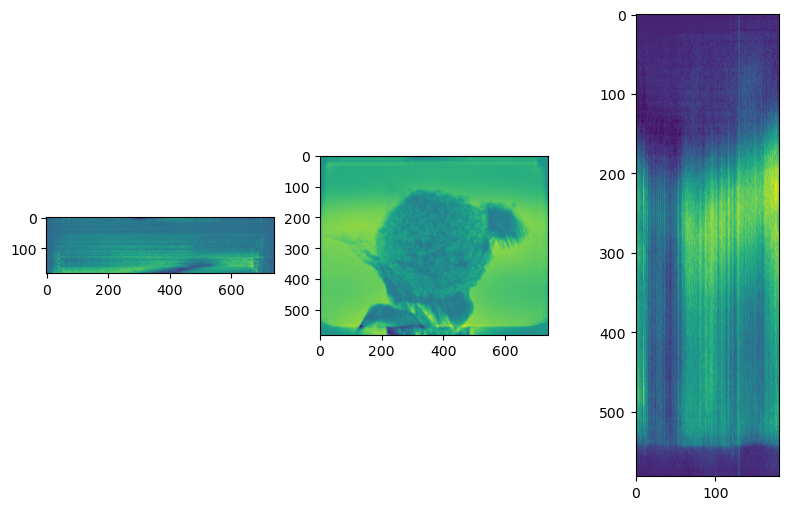

In [71]:
fig, axs = plt.subplots(1,3, figsize=(10,6))
axs[0].imshow(stack_object.real[0,:,:])
axs[1].imshow(stack_object.real[:,0,:])
axs[2].imshow(stack_object.real[:,:,0])

In [73]:
def init_astra(Nx, Ny, angles ):
    # TO-DO: add lamino angles, tilt angles, pixel scaling, rotation centre, skewness

    # Volume
    Nz = Ny
    vol_geom = astra.create_vol_geom(Nx, Ny, Nz)

    # Projection geometry (3D parallel beam)
    proj_geom = astra.create_proj_geom(
        'parallel3d',
        1.0,  # detector pixel size in x
        1.0,  # detector pixel size in y   
        Ny,          
        Nx,          
        angles
    )

    return vol_geom, proj_geom

In [ ]:
def ram_lak_filter(N, d=1.0):
    """
    Ram-Lak filter for FBP
    N : number of detector pixels (projection width)
    d : frequency scaling (default=1.0)
    Returns a 1D filter of length N
    """
    # Next power of 2 for FFT efficiency
    n = max(64, 2**int(np.ceil(np.log2(2*N))))
    
    # Ramp filter
    filt = np.zeros(n//2 + 1)
    filt[1:] = 2 * np.arange(1, n//2 + 1) / n
    
    # Symmetrize for real FFT
    filt = np.concatenate([filt, filt[-2:0:-1]])
    
    return filt

In [89]:
stack_object.shape

(582, 181, 740)

In [118]:
def FBP_astra(sinogram, vol_geom, proj_geom, weights):
    Ny, Nangles, Nx = sinogram.shape

    Fsize = max(64, 2**int(np.ceil(np.log2(2*Nx))))
    pad = (Fsize - Nx) // 2
    freqs = np.fft.fftfreq(Fsize)
    ramp = np.abs(freqs)

    filtered = np.zeros_like(sinogram)
    block_size = 2048
    for start in range(0, Ny, block_size):
        end = min(start + block_size, Ny)

        for iy in range(start, end):
            for ia in range(Nangles):
                proj = sinogram[iy, ia, :]
                proj_padded = np.pad(proj, (pad,), mode='constant')

                F = np.fft.fft(proj_padded)
                F *= ramp * weights[ia]
                filtered_proj = np.real(np.fft.ifft(F))

                filtered[iy, ia, :] = filtered_proj[pad:pad+Nx]
            
    filtered = filtered.astype(np.float32)

    sino_id = astra.data3d.create('-sino', proj_geom, filtered)
    vol_id  = astra.data3d.create('-vol',  vol_geom)

    cfg = astra.astra_dict('BP3D_CUDA')
    cfg['ProjectionDataId'] = sino_id
    cfg['ReconstructionDataId'] = vol_id

    alg_id = astra.algorithm.create(cfg)
    astra.algorithm.run(alg_id)

    rec = astra.data3d.get(vol_id)

    astra.algorithm.delete(alg_id)
    astra.data3d.delete(sino_id)
    astra.data3d.delete(vol_id)

    return rec


In [107]:
dtheta = np.zeros_like(theta)
dtheta[1:-1] = (theta[2:] - theta[:-2]) / 2
dtheta[0] = theta[1] - theta[0]
dtheta[-1] = theta[-1] - theta[-2]
# print(dtheta)
weights = dtheta / np.mean(dtheta)
print(weights)


[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [119]:
vol_geom, proj_geom = init_astra(Nx, Ny, theta)
rec = FBP_astra(stack_object, vol_geom, proj_geom, weights)


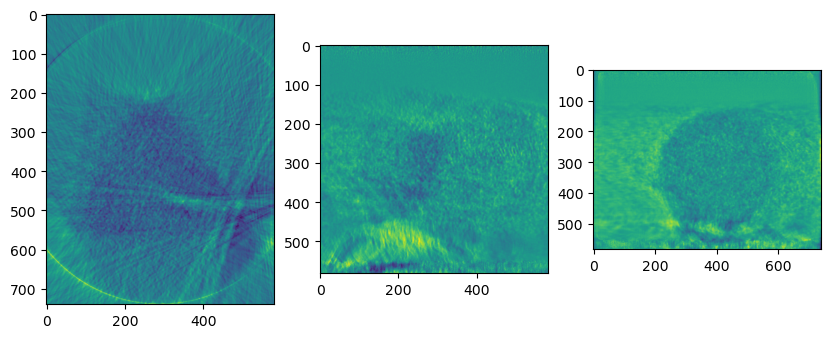

In [120]:
fig, axs = plt.subplots(1,3, figsize=(10,6))
i = 250
axs[0].imshow(rec[i,:,:])
axs[1].imshow(rec[:,i,:])
axs[2].imshow(rec[:,:,i])